# Emotion Recognition System: Validation and Deployment

This notebook builds and validates an **emotion recognition system** that detects
three emotional states — **excitement**, **frustration**, and **neutral** — from
physiological sensor data (EDA and PPG) recorded during Mortal Kombat gameplay.

### Structure

1. **Relabelling** — map ground-truth emotion annotations onto feature windows
2. **Data overview** — inspect the labelled features and sensor availability
3. **System validation (LOSO-CV)** — estimate generalisation performance on unseen subjects
4. **Analysis** — confusion matrices, feature importance, per-subject and modality breakdowns
5. **Train the final system** — build the deployable EmotionPredictor on all data
6. **Live demonstration** — run the system on raw sensor recordings

### Labels

Emotion labels come from per-moment annotations (80% self-report + 20% observer ratings),
**not** from the game difficulty condition (easy/hard). Each 30-second feature window is
labelled based on which annotated emotional moments fall within it. Windows with no
annotations or ambiguous ties between excitement and frustration are dropped.

In [2]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from models.config import (
    RF_PARAMS, SVM_PARAMS, SVM_GRID,
    PPG_FEATURES, EDA_FEATURES, ALL_FEATURES,
    RANDOM_SEED, CLASS_NAMES,
)
from models.train import run_all_experiments, summary_table
from models.analysis import (
    plot_confusion_matrices, per_subject_table,
    plot_per_subject_accuracy, compute_feature_importance,
    plot_modality_comparison, full_metrics_table,
    save_all_results,
)
from models.predict import EmotionPredictor
from data_processing.preprocessing import load_and_clean
from data_processing.relabel import relabel_features

RAW_FEATURES_CSV = os.path.join('features', 'combined_features_windowed.csv')
EMOTION_FEATURES_CSV = os.path.join('features', 'emotion_features.csv')
LABELS_FOLDER = os.path.join('..', 'data_collection_and_label_synch', 'labelling', 'labels')
TIMES_CSV = os.path.join('..', 'data_collection_and_label_synch', 'data', 'times.csv')
RESULTS_DIR = 'results'
MODEL_DIR = os.path.join('models', 'trained')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('Configuration:')
print(f'  Classes:    {CLASS_NAMES}')
print(f'  RF params:  {RF_PARAMS}')
print(f'  SVM params: {SVM_PARAMS}')
print(f'  Seed:       {RANDOM_SEED}')

Configuration:
  Classes:    ['excitement', 'frustration', 'neutral']
  RF params:  {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3, 'class_weight': 'balanced', 'random_state': 42}
  SVM params: {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale', 'class_weight': 'balanced', 'random_state': 42}
  Seed:       42


---
## 1. Relabelling — Ground-Truth Emotion Annotations

The raw feature windows carry the game condition label (easy/hard), which describes
the **game difficulty** — not the player's emotion. A player can feel frustrated during
easy mode and excited during hard mode.

Here we replace those labels with the actual emotion annotations from the labelling
protocol (80% self-report + 20% observer). Each 30-second window is assigned the
dominant emotion among the annotated moments that fall within it.

Windows with no annotated moments, or with a true tie between excitement and
frustration, are dropped.

In [3]:
emotion_df, relabel_summary = relabel_features(
    features_csv_path=RAW_FEATURES_CSV,
    labels_folder=LABELS_FOLDER,
    times_csv_path=TIMES_CSV,
    output_csv_path=EMOTION_FEATURES_CSV,
    window_sec=30.0,
)

print(f'\nTotal annotated moments used: {relabel_summary["total_moments"]}')
print(f'Windows retained: {relabel_summary["windows_after"]} / {relabel_summary["windows_before"]}')
print(f'Windows dropped: {relabel_summary["windows_dropped"]} (no annotation or ambiguous tie)')

Relabelled: 88/121 windows kept (33 dropped)
Label distribution: {'excitement': 51, 'frustration': 24, 'neutral': 13}
Saved to: features\emotion_features.csv

Total annotated moments used: 77
Windows retained: 88 / 121
Windows dropped: 33 (no annotation or ambiguous tie)


---
## 2. Data Overview

In [4]:
X, y, groups, df_clean = load_and_clean(EMOTION_FEATURES_CSV)

print(f'Total windows: {len(X)}')
print(f'Features:      {X.shape[1]}')
print(f'Subjects:      {sorted(groups.unique())}')
print()
print('Class distribution:')
display(y.value_counts().rename('count').to_frame())
print()
print('Windows per subject and emotion:')
display(df_clean.groupby(['sub_id', 'label']).size().unstack(fill_value=0))

Total windows: 88
Features:      21
Subjects:      ['1', '2', '3', '4', '5', '6', '7']

Class distribution:


,count
label,
excitement,51
frustration,24
neutral,13



Windows per subject and emotion:


label,excitement,frustration,neutral
sub_id,,,
1,7,6,2
2,9,5,0
3,8,2,4
4,8,2,2
5,5,4,1
6,8,3,0
7,6,2,4


In [5]:
ppg_cols = [c for c in PPG_FEATURES if c in X.columns]
ppg_available = ~X[ppg_cols].isnull().all(axis=1)
print(f'Windows with PPG data: {ppg_available.sum()} / {len(X)} ({ppg_available.mean()*100:.1f}%)')
print(f'Windows with EDA data: {len(X)} / {len(X)} (100%)')

Windows with PPG data: 39 / 88 (44.3%)
Windows with EDA data: 88 / 88 (100%)


---
## 3. System Validation — Leave-One-Subject-Out Cross-Validation

We evaluate two models (Random Forest, SVM) across three modality configurations
to estimate how the system performs on a person it has never seen.

### Intermediate Fusion

In addition to early fusion (raw feature concatenation) and single-modality experiments,
we evaluate **intermediate fusion** — a "Process First, Merge Later" strategy where each
modality's features are independently transformed into a reduced latent representation
before being concatenated and classified.

**Architecture:** EDA features (8) and PPG features (13) each pass through a separate
`StandardScaler` → `PCA` pipeline that retains 95% of variance. The PCA-reduced
representations are then concatenated and fed to the classifier (RF or SVM).

This approach reduces noise and redundancy within each modality before fusion, and avoids
the curse of dimensionality when training on only 88 samples.

In [6]:
experiments, X_exp, y_exp, groups_exp, df_exp = run_all_experiments(
    EMOTION_FEATURES_CSV, output_dir=RESULTS_DIR
)

Running: RF_EDA-only ... F1=0.291  Acc=0.455  (n=88)
Running: RF_Combined ... F1=0.245  Acc=0.443  (n=88)
Running: RF_PPG-only ... F1=0.516  Acc=0.564  (n=39)
Running: SVM_EDA-only ... F1=0.212  Acc=0.250  (n=88)
Running: SVM_Combined ... F1=0.275  Acc=0.307  (n=88)
Running: SVM_PPG-only ... F1=0.219  Acc=0.410  (n=39)

Intermediate Fusion experiments:
Running: RF_IntermediateFusion ... F1=0.400  Acc=0.466  (n=88)
Running: SVM_IntermediateFusion ... F1=0.252  Acc=0.307  (n=88)

SVM hyperparameter sweep on EDA-only:
  C=0.1   gamma=scale  => F1=0.227
  C=0.1   gamma=auto   => F1=0.227
  C=1.0   gamma=scale  => F1=0.212
  C=1.0   gamma=auto   => F1=0.212
  C=10.0  gamma=scale  => F1=0.256
  C=10.0  gamma=auto   => F1=0.256
  Best: C=10.0, gamma=scale, F1=0.256


### 3.1 Summary Comparison

In [7]:
summary = summary_table(experiments)
display(summary.style.format({
    'Accuracy': '{:.3f}', 'Macro_F1': '{:.3f}',
    'Macro_Precision': '{:.3f}', 'Macro_Recall': '{:.3f}',
}).highlight_max(subset=['Macro_F1'], color='#d4edda'))

,Experiment,Model,Modality,N_samples,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,RF_PPG-only,RF,PPG-only,39,0.564,0.516,0.470,0.604
1,RF_IntermediateFusion,RF,IntermediateFusion,88,0.466,0.400,0.396,0.408
2,RF_EDA-only,RF,EDA-only,88,0.455,0.291,0.279,0.306
3,SVM_Combined,SVM,Combined,88,0.307,0.275,0.299,0.285
4,SVM_IntermediateFusion,SVM,IntermediateFusion,88,0.307,0.252,0.262,0.256
5,RF_Combined,RF,Combined,88,0.443,0.245,0.229,0.270
6,SVM_PPG-only,SVM,PPG-only,39,0.410,0.219,0.209,0.230
7,SVM_EDA-only,SVM,EDA-only,88,0.250,0.212,0.248,0.251


### 3.2 Detailed Metrics

In [8]:
metrics = full_metrics_table(experiments)
display(metrics.round(3))

,Experiment,N,Accuracy,Macro_F1,Macro_Prec,Macro_Rec,Kappa,Fold_Acc_Mean,Fold_Acc_Std,Fold_Acc_Min,Fold_Acc_Max,excitement_precision,excitement_recall,excitement_f1,frustration_precision,frustration_recall,frustration_f1,neutral_precision,neutral_recall,neutral_f1
0,RF_EDA-only,88,0.455,0.291,0.279,0.306,-0.029,0.450,0.091,0.273,0.583,0.576,0.667,0.618,0.261,0.250,0.255,0.000,0.000,0.000
1,RF_Combined,88,0.443,0.245,0.229,0.270,-0.094,0.446,0.072,0.286,0.500,0.569,0.725,0.638,0.118,0.083,0.098,0.000,0.000,0.000
2,RF_PPG-only,39,0.564,0.516,0.470,0.604,0.104,0.624,0.165,0.500,1.000,0.643,0.720,0.679,0.167,0.091,0.118,0.600,1.000,0.750
3,SVM_EDA-only,88,0.250,0.212,0.248,0.251,-0.105,0.244,0.116,0.083,0.400,0.450,0.176,0.254,0.226,0.500,0.312,0.067,0.077,0.071
4,SVM_Combined,88,0.307,0.275,0.299,0.285,-0.060,0.315,0.117,0.167,0.500,0.567,0.333,0.420,0.194,0.292,0.233,0.136,0.231,0.171
5,SVM_PPG-only,39,0.410,0.219,0.209,0.230,-0.281,0.319,0.210,0.000,0.500,0.536,0.600,0.566,0.091,0.091,0.091,0.000,0.000,0.000
6,RF_IntermediateFusion,88,0.466,0.400,0.396,0.408,0.083,0.466,0.114,0.250,0.600,0.625,0.588,0.606,0.250,0.250,0.250,0.312,0.385,0.345
7,SVM_IntermediateFusion,88,0.307,0.252,0.262,0.256,-0.113,0.308,0.139,0.083,0.500,0.538,0.412,0.467,0.111,0.125,0.118,0.136,0.231,0.171


---
## 4. Analysis

### 4.1 Confusion Matrices

Saved: results\confusion_matrix_RF_EDA-only.png
Saved: results\confusion_matrix_RF_Combined.png
Saved: results\confusion_matrix_SVM_EDA-only.png
Saved: results\confusion_matrix_SVM_Combined.png
Saved: results\confusion_matrix_RF_IntermediateFusion.png
Saved: results\confusion_matrix_SVM_IntermediateFusion.png


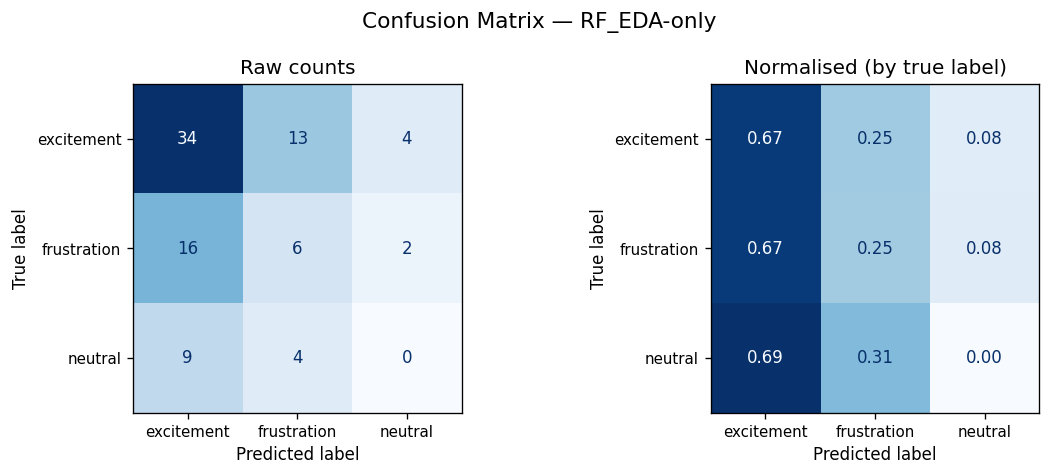

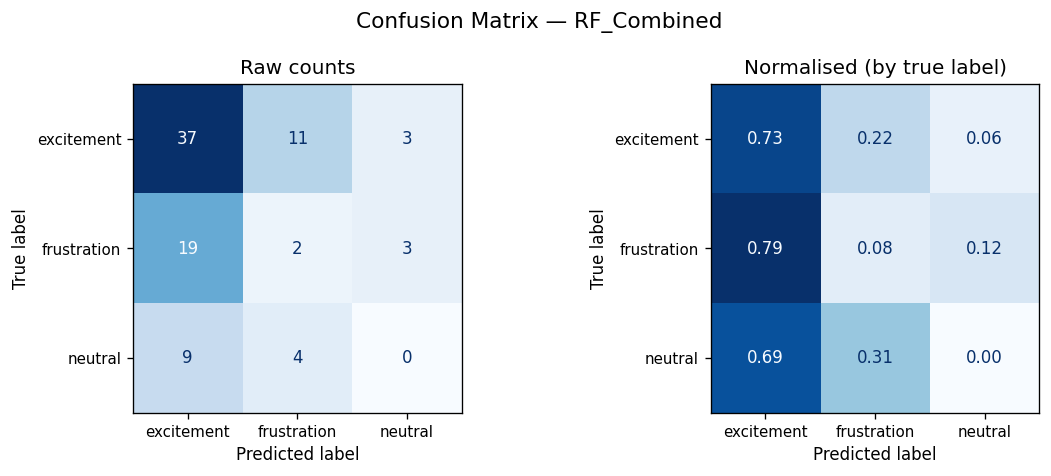

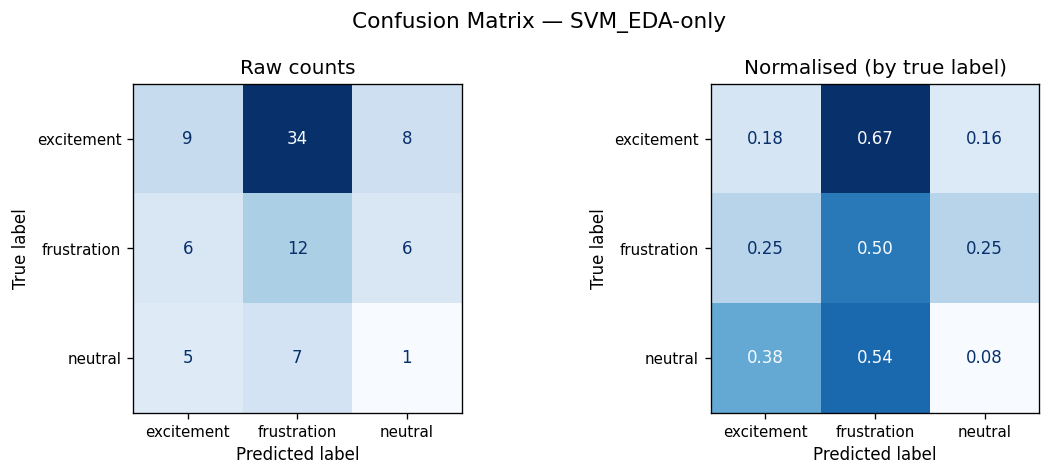

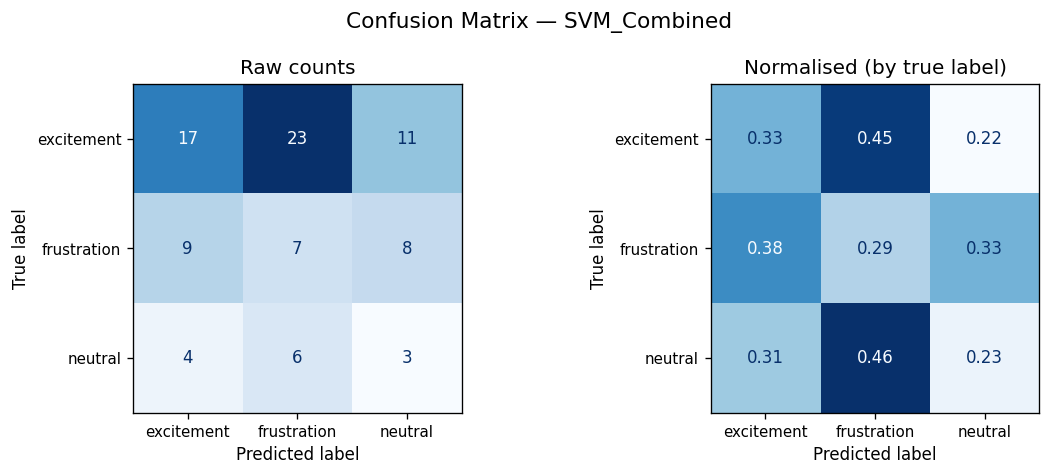

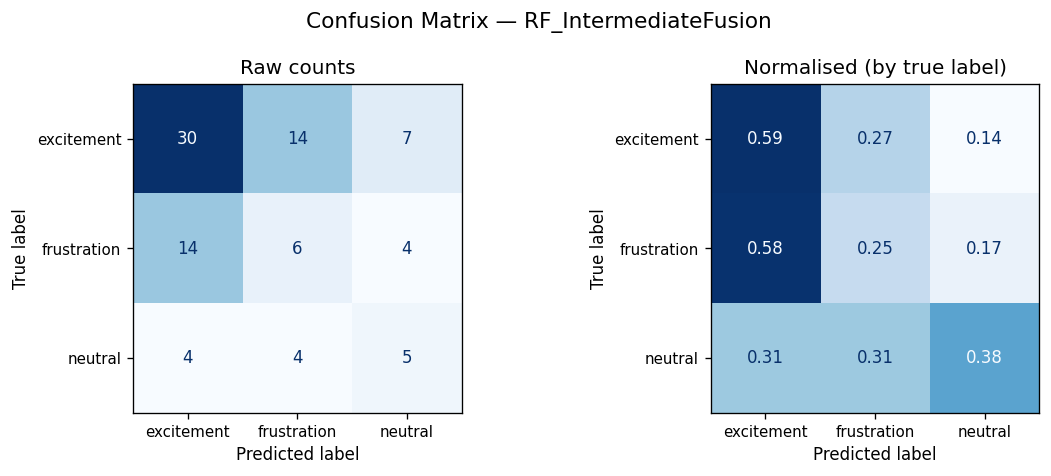

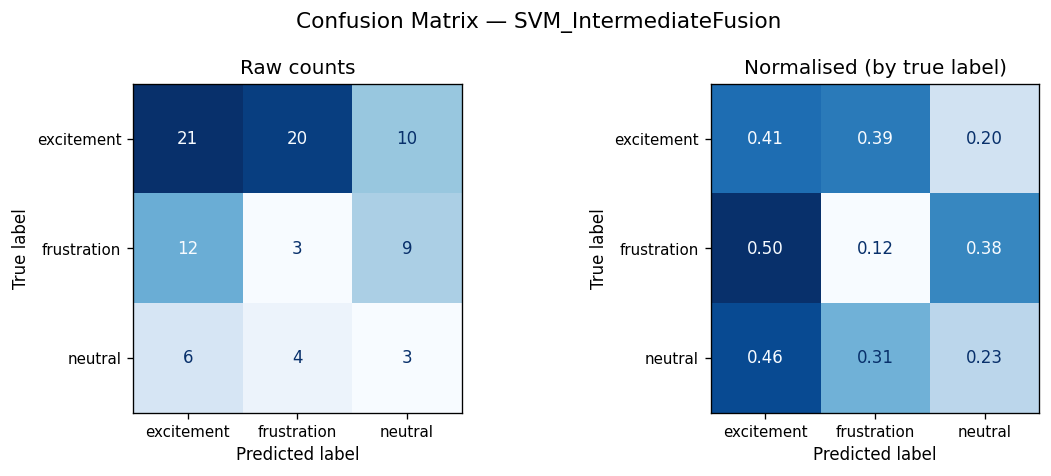

In [9]:
primary_keys = ['RF_EDA-only', 'RF_Combined', 'SVM_EDA-only', 'SVM_Combined',
                'RF_IntermediateFusion', 'SVM_IntermediateFusion']
primary_keys = [k for k in primary_keys if k in experiments]
plot_confusion_matrices(experiments, primary_keys, RESULTS_DIR)
plt.show()

### 4.2 Per-Subject Accuracy Breakdown

Experiment,RF_Combined,RF_EDA-only,RF_IntermediateFusion,SVM_Combined,SVM_EDA-only,SVM_IntermediateFusion
Subject,,,,,,
1,0.467,0.467,0.467,0.200,0.400,0.400
2,0.286,0.429,0.500,0.214,0.214,0.143
3,0.500,0.500,0.500,0.429,0.357,0.357
4,0.417,0.583,0.583,0.333,0.083,0.500
5,0.500,0.400,0.600,0.500,0.300,0.400
6,0.455,0.273,0.364,0.364,0.273,0.273
7,0.500,0.500,0.250,0.167,0.083,0.083



Saved: results\per_subject_accuracy.png


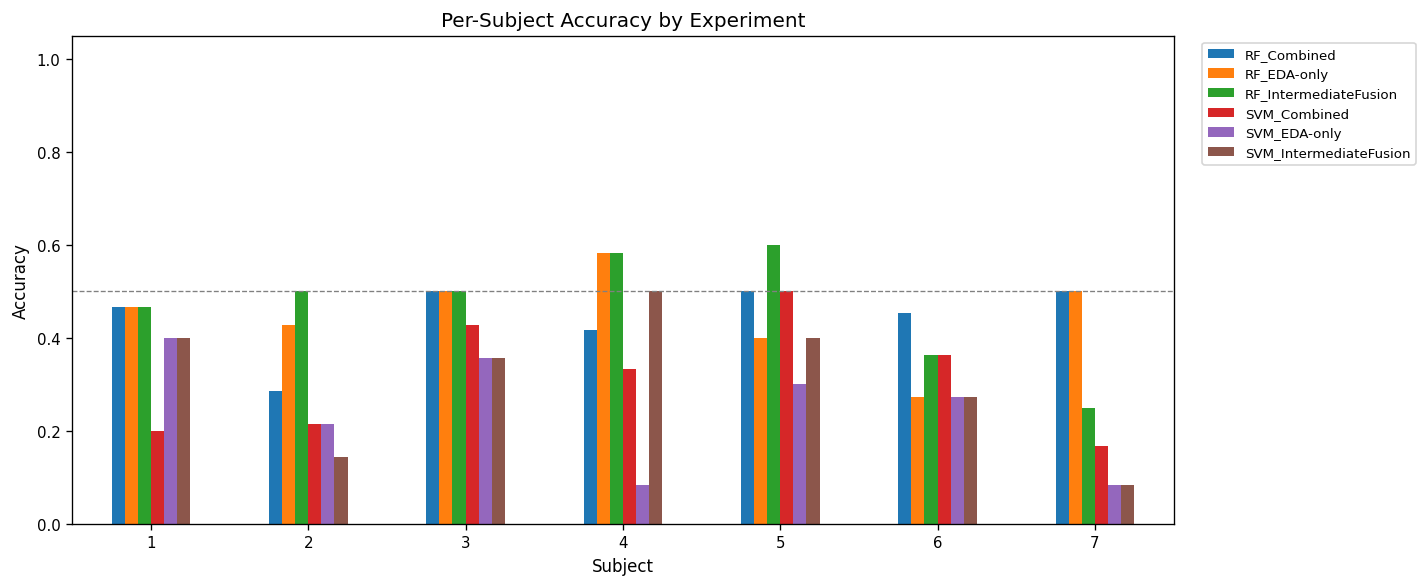

In [10]:
sub_df = per_subject_table(experiments, primary_keys)
display(sub_df.pivot_table(index='Subject', columns='Experiment', values='Accuracy').round(3))
print()
plot_per_subject_accuracy(experiments, primary_keys, RESULTS_DIR)
plt.show()

### 4.3 Feature Importance

Saved: results\feature_importance.png


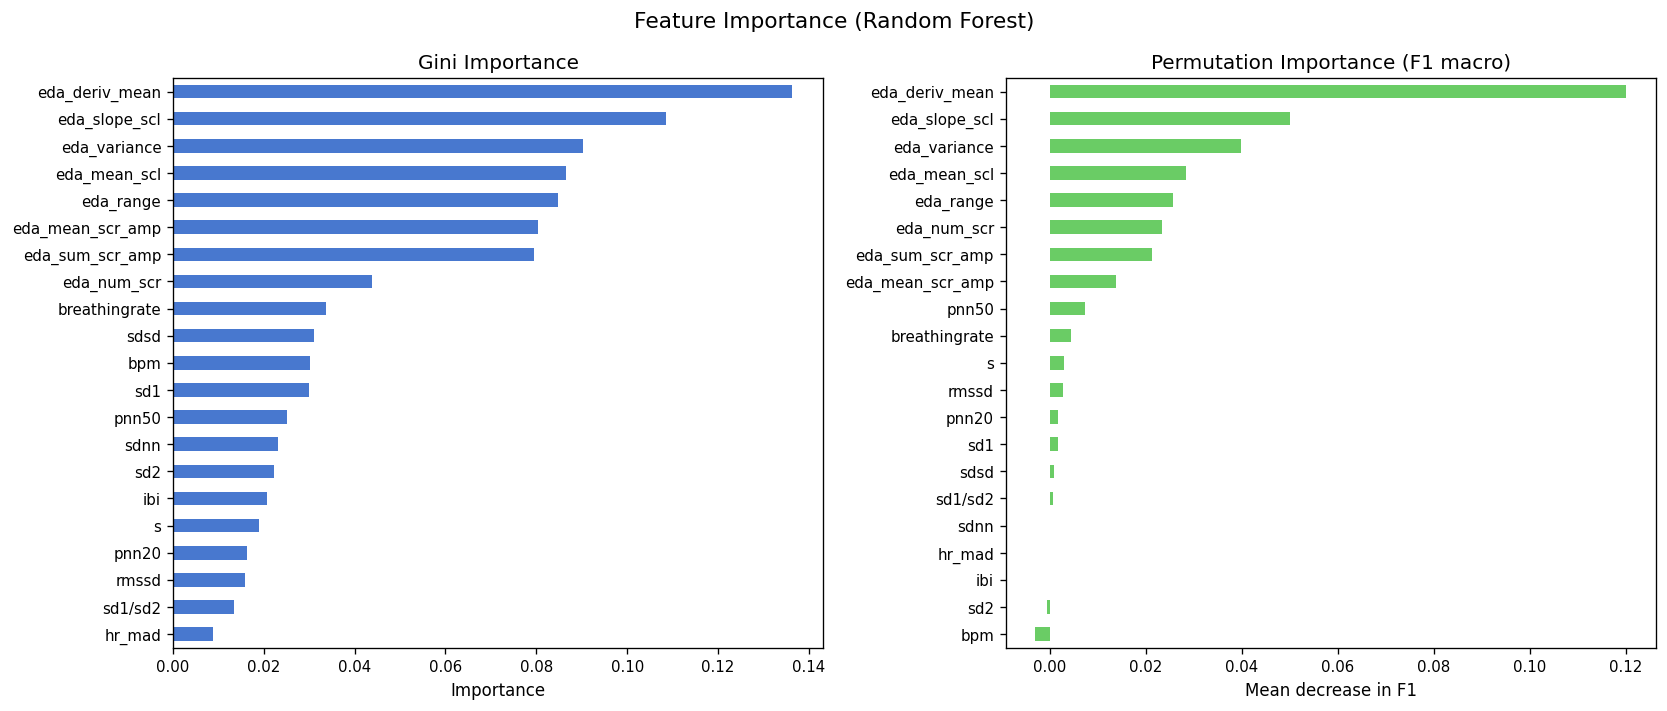


Top 5 features by Gini importance:


,importance
eda_deriv_mean,0.136330
eda_slope_scl,0.108602
eda_variance,0.090205
eda_mean_scl,0.086540
eda_range,0.084866



Top 5 features by permutation importance:


,importance
eda_deriv_mean,0.120151
eda_slope_scl,0.050010
eda_variance,0.039798
eda_mean_scl,0.028251
eda_range,0.025616


In [11]:
available_feats = [c for c in ALL_FEATURES if c in X_exp.columns]
gini_imp, perm_imp = compute_feature_importance(
    X_exp, y_exp, groups_exp, available_feats, RESULTS_DIR
)
plt.show()
print('\nTop 5 features by Gini importance:')
display(gini_imp.sort_values(ascending=False).head(5).to_frame('importance'))
print('\nTop 5 features by permutation importance:')
display(perm_imp.sort_values(ascending=False).head(5).to_frame('importance'))

### 4.4 Modality Comparison

Saved: results\modality_comparison.png


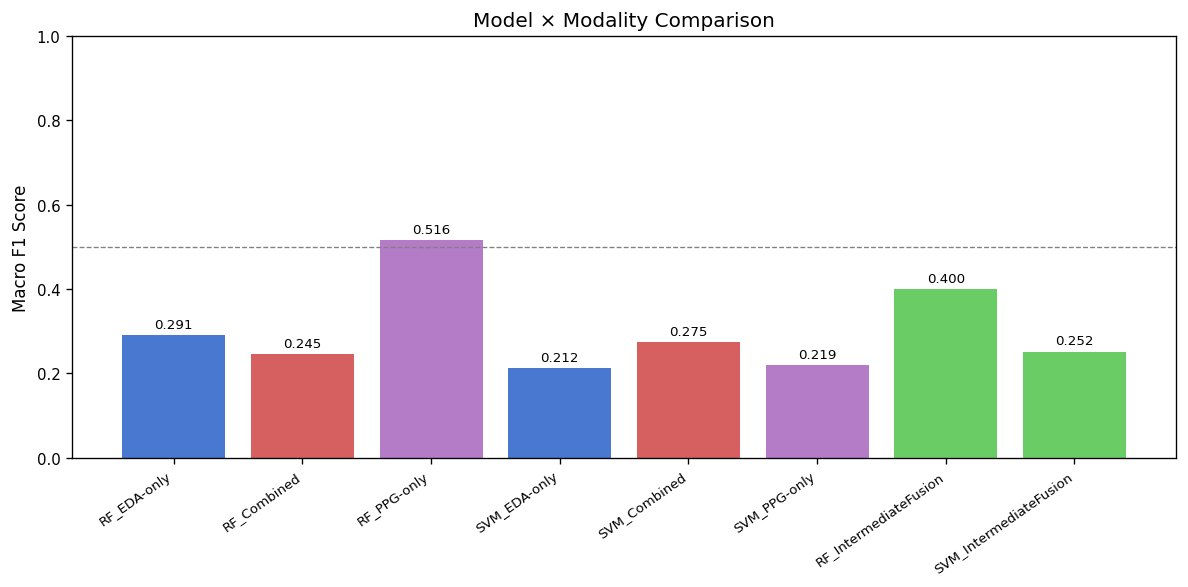

,Experiment,N,Accuracy,Macro_F1,Kappa
0,RF_EDA-only,88,0.455,0.291,-0.029
1,RF_Combined,88,0.443,0.245,-0.094
2,RF_PPG-only,39,0.564,0.516,0.104
3,RF_IntermediateFusion,88,0.466,0.400,0.083


In [12]:
plot_modality_comparison(experiments, RESULTS_DIR)
plt.show()

fusion_keys = ['RF_EDA-only', 'RF_Combined', 'RF_PPG-only', 'RF_IntermediateFusion']
fusion_keys = [k for k in fusion_keys if k in experiments]
fusion_df = full_metrics_table(experiments, fusion_keys)
display(fusion_df[['Experiment', 'N', 'Accuracy', 'Macro_F1', 'Kappa']].round(3))

### 4.5 Save All Validation Results

In [13]:
final_metrics = save_all_results(experiments, X_exp, y_exp, groups_exp, RESULTS_DIR)
print('\nAll validation results saved to:', RESULTS_DIR)
print('Files:')
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f'  {f}')

Saved: results\confusion_matrix_RF_EDA-only.png
Saved: results\confusion_matrix_RF_Combined.png
Saved: results\confusion_matrix_RF_PPG-only.png
Saved: results\confusion_matrix_SVM_EDA-only.png
Saved: results\confusion_matrix_SVM_Combined.png
Saved: results\confusion_matrix_SVM_PPG-only.png
Saved: results\confusion_matrix_RF_IntermediateFusion.png
Saved: results\confusion_matrix_SVM_IntermediateFusion.png
Saved: results\per_subject_accuracy.png
Saved: results\feature_importance.png
Saved: results\modality_comparison.png

Saved metrics summary to results\metrics_summary.csv

All validation results saved to: results
Files:
  RF_Combined_predictions.csv
  RF_EDA-only_predictions.csv
  RF_IntermediateFusion_predictions.csv
  RF_PPG-only_predictions.csv
  SVM_Combined_predictions.csv
  SVM_EDA-only_predictions.csv
  SVM_IntermediateFusion_predictions.csv
  SVM_PPG-only_predictions.csv
  confusion_matrix_RF_Combined.png
  confusion_matrix_RF_EDA-only.png
  confusion_matrix_RF_IntermediateFusi

---
## 5. Train the Final Emotion Recognition System

The LOSO-CV above established generalisation performance. Now we train the final
deployable model on all available data to give it the maximum number of physiological
patterns to learn from. The LOSO-CV metrics are the expected real-world performance.

In [14]:
predictor = EmotionPredictor()
predictor.train_from_features(EMOTION_FEATURES_CSV)

model_path = os.path.join(MODEL_DIR, 'emotion_model.pkl')
predictor.save(model_path)

print(f'\nExpected generalisation performance (from LOSO-CV):')
best = summary.iloc[0]
print(f'  Best configuration: {best["Experiment"]}')
print(f'  Macro F1:           {best["Macro_F1"]:.3f}')
print(f'  Accuracy:           {best["Accuracy"]:.3f}')

Trained on 88 windows, training accuracy: 0.966
Classes: ['excitement', 'frustration', 'neutral']
Model saved to models\trained\emotion_model.pkl

Expected generalisation performance (from LOSO-CV):
  Best configuration: RF_PPG-only
  Macro F1:           0.516
  Accuracy:           0.564


---
## 6. Live Demonstration — Emotion Prediction from Raw Sensor Data

The system takes raw EDA sensor recordings and produces per-window emotion
predictions with confidence scores — excitement, frustration, or neutral.

In [15]:
deployed_model = EmotionPredictor.load(model_path)
print('Emotion recognition system loaded from disk.')
print(f'  Classes:     {list(deployed_model.model.classes_)}')
print(f'  Window size: {deployed_model.window_sec}s at {deployed_model.sample_rate} Hz')

Emotion recognition system loaded from disk.
  Classes:     ['excitement', 'frustration', 'neutral']
  Window size: 30s at 64.0 Hz


In [16]:
def demo_recording(filepath, subject_label):
    raw = pd.read_csv(filepath)
    eda = raw['EDA'].to_numpy(dtype=float)
    eda = eda[int(5 * deployed_model.sample_rate):]
    results = deployed_model.predict_stream(eda, stride_sec=15)
    print(f'{subject_label} ({len(eda)/deployed_model.sample_rate:.0f}s of EDA data)')
    print('-' * 65)
    for r in results:
        bar = chr(9608) * int(r['confidence'] * 20)
        print(f'  {r["time_start_sec"]:5.0f}s - {r["time_end_sec"]:5.0f}s | '
              f'{r["prediction"]:<12s} | '
              f'{r["confidence"]:.2f} {bar}')
    print()

demo_recording('../data_collection_and_label_synch/data/labelled_data/full_labelled_003-easy.csv', 'Subject 003 - easy mode')
demo_recording('../data_collection_and_label_synch/data/labelled_data/full_labelled_003-hard.csv', 'Subject 003 - hard mode')

Subject 003 - easy mode (119s of EDA data)
-----------------------------------------------------------------
      0s -    30s | excitement   | 0.62 ████████████
     15s -    45s | excitement   | 0.48 █████████
     30s -    60s | excitement   | 0.44 ████████
     45s -    75s | excitement   | 0.46 █████████
     60s -    90s | excitement   | 0.37 ███████
     75s -   105s | excitement   | 0.51 ██████████

Subject 003 - hard mode (150s of EDA data)
-----------------------------------------------------------------
      0s -    30s | excitement   | 0.48 █████████
     15s -    45s | excitement   | 0.44 ████████
     30s -    60s | frustration  | 0.43 ████████
     45s -    75s | excitement   | 0.48 █████████
     60s -    90s | excitement   | 0.46 █████████
     75s -   105s | frustration  | 0.49 █████████
     90s -   120s | frustration  | 0.55 ██████████
    105s -   135s | excitement   | 0.66 █████████████



In [17]:
demo_recording('../data_collection_and_label_synch/data/labelled_data/full_labelled_005-easy.csv', 'Subject 005 - easy mode')
demo_recording('../data_collection_and_label_synch/data/labelled_data/full_labelled_005-hard.csv', 'Subject 005 - hard mode')

Subject 005 - easy mode (94s of EDA data)
-----------------------------------------------------------------
      0s -    30s | excitement   | 0.53 ██████████
     15s -    45s | excitement   | 0.49 █████████
     30s -    60s | excitement   | 0.68 █████████████
     45s -    75s | excitement   | 0.45 ████████
     60s -    90s | excitement   | 0.65 █████████████

Subject 005 - hard mode (160s of EDA data)
-----------------------------------------------------------------
      0s -    30s | frustration  | 0.57 ███████████
     15s -    45s | excitement   | 0.51 ██████████
     30s -    60s | frustration  | 0.47 █████████
     45s -    75s | excitement   | 0.49 █████████
     60s -    90s | excitement   | 0.59 ███████████
     75s -   105s | excitement   | 0.34 ██████
     90s -   120s | excitement   | 0.42 ████████
    105s -   135s | excitement   | 0.63 ████████████
    120s -   150s | excitement   | 0.65 █████████████



In [18]:
print('Single-window prediction example:')
print()
raw = pd.read_csv('../data_collection_and_label_synch/data/labelled_data/full_labelled_003-hard.csv')
sample_eda = raw['EDA'].iloc[320:2240].to_numpy(dtype=float)
result = deployed_model.predict_from_raw(sample_eda)
print(f'  Input:       30 seconds of raw EDA from Subject 003, hard mode')
print(f'  Prediction:  {result["prediction"]}')
print(f'  Confidence:  {result["confidence"]:.2f}')
print(f'  Probabilities:')
for cls, prob in sorted(result['probabilities'].items()):
    print(f'    {cls:<12s} {prob:.3f}')
print()
print('Core API: result = predictor.predict_from_raw(eda_window)')

Single-window prediction example:

  Input:       30 seconds of raw EDA from Subject 003, hard mode
  Prediction:  excitement
  Confidence:  0.48
  Probabilities:
    excitement   0.476
    frustration  0.393
    neutral      0.132

Core API: result = predictor.predict_from_raw(eda_window)
